# Notebook 05 — Modelo de precipitación Bernoulli-Gamma

## 1. Preparación del modelo Bernoulli–Gamma

En esta etapa se construye la variable de ocurrencia de lluvia.
La precipitación se separa en dos procesos:

- Ocurrencia: si llueve o no (Bernoulli)
- Intensidad: cuánto llueve (Gamma)

Definimos una variable binaria `rain_flag` que indica días lluviosos.

In [2]:
#Traer datos
import pandas as pd
df = pd.read_excel('../data/simulated_climate_rice_2000_2025.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Creamos variable binaria: 1 si llueve, 0 si no llueve
df['rain_flag'] = (df['Precipitation_mm'] > 0).astype(int)

## 2. Modelo de ocurrencia de lluvia (Bernoulli - Logit)

En este paso se modela la probabilidad de que ocurra lluvia en un día:

$$
P(P_t > 0) = p_t
$$

Usamos un modelo logístico (Logit), donde la variable dependiente es binaria:
- 1 = día con lluvia
- 0 = día sin lluvia

Se incorporan variables climáticas relevantes:
- Temperatura promedio
- Temperatura máxima
- Temperatura mínima

Estas variables ayudan a capturar cambios atmosféricos que afectan la ocurrencia de precipitación.

In [3]:
import statsmodels.api as sm  # modelos estadísticos

# Variable objetivo: 1 si llueve, 0 si no llueve
y = (df['Precipitation_mm'] > 0).astype(int)

# Variables explicativas (temperaturas)
X = df[['Temperature_Avg_C', 'Temperature_Max_C', 'Temperature_Min_C']]

# Se agrega intercepto al modelo
X = sm.add_constant(X)

# Ajuste del modelo logístico Bernoulli
logit_model = sm.Logit(y, X).fit()

# Resumen del modelo
print(logit_model.summary())



Optimization terminated successfully.
         Current function value: 0.561990
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:       Precipitation_mm   No. Observations:                 9497
Model:                          Logit   Df Residuals:                     9493
Method:                           MLE   Df Model:                            3
Date:                Sat, 23 May 2026   Pseudo R-squ.:                0.001179
Time:                        06:36:56   Log-Likelihood:                -5337.2
converged:                       True   LL-Null:                       -5343.5
Covariance Type:            nonrobust   LLR p-value:                  0.005597
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.4874      0.232     -2.099      0.036      -0.943      -0.032
Temperat

## 3. Estimación de probabilidad de lluvia

Con el modelo ajustado se calcula la probabilidad diaria de precipitación.

Esto será usado posteriormente para simular la ocurrencia de lluvia.

In [4]:
# Probabilidad estimada de lluvia
df['p_rain'] = logit_model.predict(X)

## 4. Modelo de intensidad de lluvia (Gamma)

Se modela la cantidad de precipitación en días lluviosos usando una distribución Gamma.

La media de la Gamma depende de variables climáticas:

- Temperatura promedio
- Temperatura máxima
- Temperatura mínima

Esto permite capturar cómo las condiciones térmicas afectan la intensidad de la lluvia.

In [5]:
import numpy as np  # operaciones numéricas

# Solo días con lluvia
df_rain = df[df['Precipitation_mm'] > 0].copy()

# Variables explicativas (mismas del logit)
Xg = df_rain[['Temperature_Avg_C', 'Temperature_Max_C', 'Temperature_Min_C']]

# Intercepto
Xg = sm.add_constant(Xg)

# Variable objetivo: intensidad de lluvia
yg = df_rain['Precipitation_mm']

# Modelo Gamma con link log (garantiza positividad)
gamma_model = sm.GLM(
    yg,
    Xg,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

print(gamma_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       Precipitation_mm   No. Observations:                 2377
Model:                            GLM   Df Residuals:                     2373
Model Family:                   Gamma   Df Model:                            3
Link Function:                    log   Scale:                         0.52289
Method:                          IRLS   Log-Likelihood:                -8605.3
Date:                Sat, 23 May 2026   Deviance:                       1302.2
Time:                        06:36:56   Pearson chi2:                 1.24e+03
No. Iterations:                    10   Pseudo R-squ. (CS):           0.001356
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.7356      0.14

c:\Users\jhoan\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


## 5. Simulación del proceso completo de precipitación

Se simula la precipitación en dos etapas:

1. Bernoulli → determina si llueve o no
2. Gamma → genera intensidad si hay lluvia

La simulación usa los parámetros estimados del modelo ajustado.

In [6]:
import numpy as np

# 1. Probabilidad de lluvia (todos los días)
p_rain = logit_model.predict(X)

# 2. Simulación de ocurrencia (mismo tamaño)
occurrence = np.random.binomial(1, p_rain)

# 3. Media de intensidad (para TODOS los días, no solo lluvia)
Xg_full = df[['Temperature_Avg_C', 'Temperature_Max_C', 'Temperature_Min_C']]
Xg_full = sm.add_constant(Xg_full)
mu_full = gamma_model.predict(Xg_full)

# 4. Shape del Gamma (estimado del modelo)
shape = gamma_model.scale  # aproximación estadística

# 5. Simulación de intensidad (solo si llueve)
rain_intensity = np.random.gamma(shape, mu_full / shape)

# 6. Precipitación final
precip_sim = occurrence * rain_intensity

## 6. Comparación del modelo con y sin estacionalidad

En este paso se comparan dos versiones del modelo de precipitación:

### 🌤️ Modelo base (sin estacionalidad)
- Utiliza únicamente variables de temperatura:
  - Temperatura promedio
  - Temperatura máxima
  - Temperatura mínima
- No considera patrones temporales del año

### 🌦️ Modelo con estacionalidad
- Incluye las mismas variables de temperatura
- Se agregan componentes cíclicos:
  - sin(2π·mes/12)
  - cos(2π·mes/12)

Estas variables permiten capturar la naturaleza periódica anual del clima.Ademas, estas transformaciones permiten representar la estacionalidad anual de forma suave y continua, evitando el uso de variables categóricas.

#### Estacionalidad en datos diarios

Aunque los datos tienen frecuencia diaria, la dinámica de la precipitación sigue un patrón estacional anual.

Por esta razón, la estacionalidad no se modela a nivel diario, sino a nivel mensual, ya que los fenómenos climáticos presentan ciclos anuales más que variaciones diarias sistemáticas.



---

## 📊 Evaluación del modelo

Para comparar el desempeño de ambos modelos se utiliza:

- **ROC-AUC**
  - Mide la capacidad de discriminación del modelo Bernoulli
  - Valores más altos indican mejor predicción de días lluviosos

- **Mejora del modelo**
  - Se calcula como la diferencia entre el ROC-AUC con estacionalidad y sin estacionalidad
  - Permite cuantificar el aporte de la estacionalidad

---

## 🌧️ Simulación del proceso completo

Una vez estimados ambos modelos:

- El modelo Bernoulli determina la ocurrencia de lluvia
- El modelo Gamma estima la intensidad de precipitación
- Se genera la precipitación simulada como producto de ambos procesos

Esto se realiza tanto para:
- El modelo base (sin estacionalidad)
- El modelo con estacionalidad

---

## 🎯 Objetivo de esta comparación

Evaluar si la inclusión de estacionalidad mejora:

- La predicción de ocurrencia de lluvia
- La coherencia del proceso simulado
- La capacidad del modelo para capturar patrones climáticos reales

In [7]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

# =========================================================
# 🌞 1. ESTACIONALIDAD
# =========================================================

# Asegurar estructura de fecha
df = df.reset_index()

# Si Date quedó como índice o columna, asegurar formato correcto
df['Date'] = pd.to_datetime(df['Date'])

# Extraer mes
df['month'] = df['Date'].dt.month

# Variables cíclicas
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)


# =========================================================
# 🌤️ 2. VARIABLE OBJETIVO
# =========================================================

y = (df['Precipitation_mm'] > 0).astype(int)
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

# Asegurar que pandas esté disponible y la estructura de fecha esté lista
df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date'])
df['month'] = df['Date'].dt.month

# Variables cíclicas
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# Variable objetivo Bernoulli (Ocurrencia)
y_logit = (df['Precipitation_mm'] > 0).astype(int)

# Filtro para el modelo Gamma (Solo días con lluvia)
df_rain = df[df['Precipitation_mm'] > 0].copy()
y_gamma = df_rain['Precipitation_mm']


# =========================================================
# 🌤️ 3 & 4. MODELOS BERNOULLI (LOGIT)
# =========================================================

# Modelo Logit Base
X_base = df[['Temperature_Avg_C', 'Temperature_Max_C', 'Temperature_Min_C']]
X_base = sm.add_constant(X_base)
logit_base = sm.Logit(y_logit, X_base).fit(disp=0)
p_base = logit_base.predict(X_base)
auc_base = roc_auc_score(y_logit, p_base)

# Modelo Logit Estacional
X_season = df[['Temperature_Avg_C', 'Temperature_Max_C', 'Temperature_Min_C', 'sin_month', 'cos_month']]
X_season = sm.add_constant(X_season)
logit_season = sm.Logit(y_logit, X_season).fit(disp=0)
p_season = logit_season.predict(X_season)
auc_season = roc_auc_score(y_logit, p_season)

print(f"ROC-AUC base: {auc_base:.4f}")
print(f"ROC-AUC estacional: {auc_season:.4f}")
print(f"Mejora en detección de ocurrencia: {auc_season - auc_base:.4f}\n")


# =========================================================
# 🛠️ FIX: AJUSTE DE LOS MODELOS GAMMA (ENTRENAMIENTO)
# =========================================================

# 1. Gamma Base (Solo temperaturas)
Xg_base_train = df_rain[['Temperature_Avg_C', 'Temperature_Max_C', 'Temperature_Min_C']]
Xg_base_train = sm.add_constant(Xg_base_train)
gamma_base_model = sm.GLM(
    y_gamma, Xg_base_train, 
    family=sm.families.Gamma(sm.families.links.log())
).fit()

# 2. Gamma Estacional (Temperaturas + Ciclos mensuales)
Xg_season_train = df_rain[['Temperature_Avg_C', 'Temperature_Max_C', 'Temperature_Min_C', 'sin_month', 'cos_month']]
Xg_season_train = sm.add_constant(Xg_season_train)
gamma_season_model = sm.GLM(
    y_gamma, Xg_season_train, 
    family=sm.families.Gamma(sm.families.links.log())
).fit()


# =========================================================
# 🌧️ 6. SIMULACIÓN PROCESO COMPLETO: CON ESTACIONALIDAD
# =========================================================
print("--- Resumen Modelo Gamma Estacional ---")
print(gamma_season_model.summary())

# Para la simulación completa necesitamos predecir sobre TODO el dataset (df)
Xg_season_full = df[['Temperature_Avg_C', 'Temperature_Max_C', 'Temperature_Min_C', 'sin_month', 'cos_month']]
Xg_season_full = sm.add_constant(Xg_season_full)

mu_season = gamma_season_model.predict(Xg_season_full)
shape_season = 1.0 / gamma_season_model.scale  # Ajuste correcto del parámetro de forma en statsmodels GLM

# Generar componentes estocásticos
rain_intensity_season = np.random.gamma(shape_season, mu_season / shape_season)
occurrence_season = np.random.binomial(1, p_season)

# Producto final
precip_sim_season = occurrence_season * rain_intensity_season


# =========================================================
# 🌧️ 7. SIMULACIÓN PROCESO COMPLETO: BASE (SIN ESTACIONALIDAD)
# =========================================================

Xg_base_full = df[['Temperature_Avg_C', 'Temperature_Max_C', 'Temperature_Min_C']]
Xg_base_full = sm.add_constant(Xg_base_full)

mu_base = gamma_base_model.predict(Xg_base_full)
shape_base = 1.0 / gamma_base_model.scale

# Generar componentes estocásticos
rain_intensity_base = np.random.gamma(shape_base, mu_base / shape_base)
occurrence_base = np.random.binomial(1, p_base)

# Producto final
precip_sim_base = occurrence_base * rain_intensity_base

ROC-AUC base: 0.5264
ROC-AUC estacional: 0.7104
Mejora en detección de ocurrencia: 0.1840

--- Resumen Modelo Gamma Estacional ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:       Precipitation_mm   No. Observations:                 2377
Model:                            GLM   Df Residuals:                     2371
Model Family:                   Gamma   Df Model:                            5
Link Function:                    log   Scale:                         0.52347
Method:                          IRLS   Log-Likelihood:                -8605.3
Date:                Sat, 23 May 2026   Deviance:                       1302.1
Time:                        06:36:56   Pearson chi2:                 1.24e+03
No. Iterations:                     9   Pseudo R-squ. (CS):           0.001376
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      

c:\Users\jhoan\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\jhoan\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


======= 📑 REPORTE DE VALIDACIÓN PARA MONTE CARLO =======

--- Comparativo Mensual de Precipitación Promedio (mm) y Frecuencia ---
       mm_Real  mm_Sim_Base  mm_Sim_Season  Frec_Real  Frec_Sim_Base  \
month                                                                  
1        0.754        3.333          1.097      0.051          0.236   
2        1.449        3.815          1.737      0.098          0.265   
3        2.752        3.855          2.338      0.180          0.233   
4        3.932        3.284          3.861      0.255          0.242   
5        5.326        3.539          5.328      0.368          0.234   
6        6.563        3.911          6.886      0.423          0.237   
7        6.787        4.177          7.932      0.440          0.268   
8        6.745        4.447          6.771      0.423          0.289   
9        5.041        4.399          4.819      0.331          0.269   
10       3.302        4.009          3.183      0.207          0.288   
11    

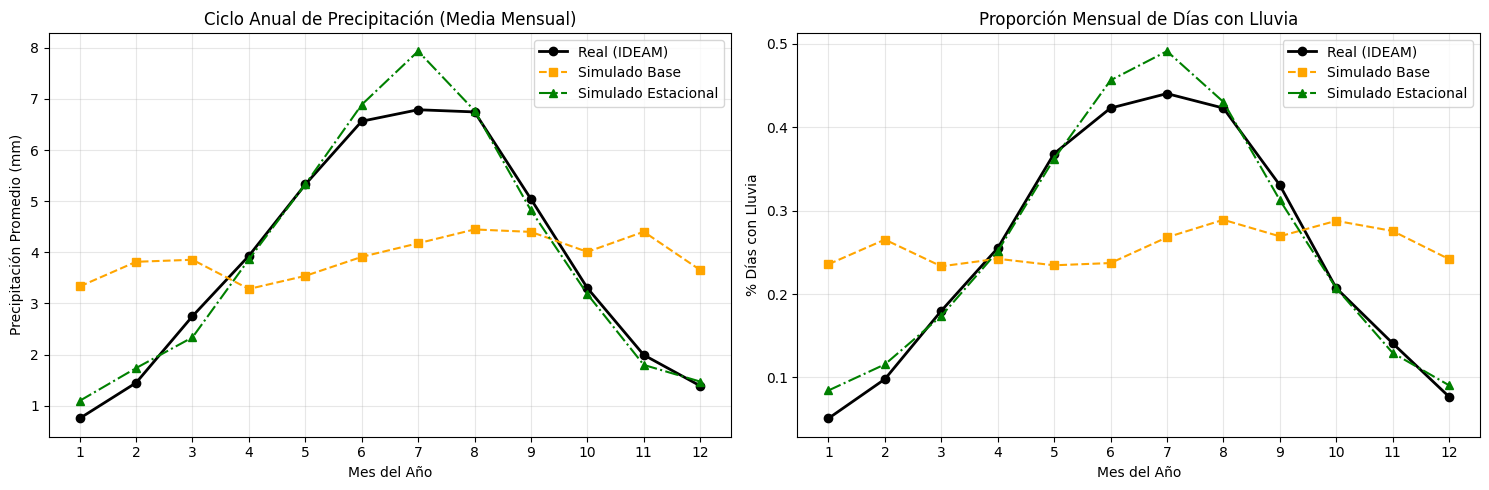

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==============================================================================
# 📊 1. PREPARACIÓN DE LAS SERIES EN EL DATAFRAME
# ==============================================================================

# Añadimos los vectores simulados al dataframe para agrupar fácilmente por mes
df['Precip_Sim_Base'] = precip_sim_base
df['Precip_Sim_Season'] = precip_sim_season

# Creamos indicadores binarios de ocurrencia (1 si llueve, 0 si no)
df['Rain_Real_Occ'] = (df['Precipitation_mm'] > 0).astype(int)
df['Rain_Base_Occ'] = (df['Precip_Sim_Base'] > 0).astype(int)
df['Rain_Season_Occ'] = (df['Precip_Sim_Season'] > 0).astype(int)


# ==============================================================================
# 📈 2. AGREGACIÓN MENSUAL (FRECUENCIA Y CANTIDAD DE LLUVIA)
# ==============================================================================

# Agrupamos por mes para ver cómo replican el ciclo anual (Bimodal/Monodal)
monthly_comparison = df.groupby('month').agg({
    'Precipitation_mm': 'mean',
    'Precip_Sim_Base': 'mean',
    'Precip_Sim_Season': 'mean',
    'Rain_Real_Occ': 'mean',  # Proporción de días lluviosos
    'Rain_Base_Occ': 'mean',
    'Rain_Season_Occ': 'mean'
}).rename(columns={
    'Precipitation_mm': 'mm_Real',
    'Precip_Sim_Base': 'mm_Sim_Base',
    'Precip_Sim_Season': 'mm_Sim_Season',
    'Rain_Real_Occ': 'Frec_Real',
    'Rain_Base_Occ': 'Frec_Sim_Base',
    'Rain_Season_Occ': 'Frec_Sim_Season'
})


# ==============================================================================
# ⏱️ 3. ANÁLISIS DE RACHAS SECAS (DRY SPELLS) PARA EL CRI
# ==============================================================================

def max_dry_spell(series):
    """Calcula la racha máxima de días consecutivos sin lluvia (0 mm)"""
    is_dry = (series == 0).astype(int)
    # Truco de cumsum para identificar bloques consecutivos de días secos
    dry_blocks = is_dry * (is_dry.groupby((is_dry != is_dry.shift()).cumsum()).cumcount() + 1)
    return dry_blocks.max()

dry_spells_report = {
    'Real (IDEAM)': max_dry_spell(df['Precipitation_mm']),
    'Modelo Base': max_dry_spell(df['Precip_Sim_Base']),
    'Modelo Estacional': max_dry_spell(df['Precip_Sim_Season'])
}


# ==============================================================================
# 🖥️ 4. DESPLIEGUE DE RESULTADOS EN CONSOLA Y GRÁFICOS
# ==============================================================================

print("======= 📑 REPORTE DE VALIDACIÓN PARA MONTE CARLO =======")
print("\n--- Comparativo Mensual de Precipitación Promedio (mm) y Frecuencia ---")
print(monthly_comparison.round(3))

print("\n--- 🌵 Máxima Racha Seca Registrada (Días consecutivos sin lluvia) ---")
for modelo, racha in dry_spells_report.items():
    print(f"  ▪️ {modelo}: {racha} días")

# Graficar comportamiento estacional
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Milímetros acumulados/promedio mensuales
ax[0].plot(monthly_comparison.index, monthly_comparison['mm_Real'], label='Real (IDEAM)', color='black', linewidth=2, marker='o')
ax[0].plot(monthly_comparison.index, monthly_comparison['mm_Sim_Base'], label='Simulado Base', color='orange', linestyle='--', marker='s')
ax[0].plot(monthly_comparison.index, monthly_comparison['mm_Sim_Season'], label='Simulado Estacional', color='green', linestyle='-.', marker='^')
ax[0].set_title('Ciclo Anual de Precipitación (Media Mensual)')
ax[0].set_xlabel('Mes del Año')
ax[0].set_ylabel('Precipitación Promedio (mm)')
ax[0].set_xticks(range(1, 13))
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Gráfico 2: Frecuencia de días lluviosos por mes
ax[1].plot(monthly_comparison.index, monthly_comparison['Frec_Real'], label='Real (IDEAM)', color='black', linewidth=2, marker='o')
ax[1].plot(monthly_comparison.index, monthly_comparison['Frec_Sim_Base'], label='Simulado Base', color='orange', linestyle='--', marker='s')
ax[1].plot(monthly_comparison.index, monthly_comparison['Frec_Sim_Season'], label='Simulado Estacional', color='green', linestyle='-.', marker='^')
ax[1].set_title('Proporción Mensual de Días con Lluvia')
ax[1].set_xlabel('Mes del Año')
ax[1].set_ylabel('% Días con Lluvia')
ax[1].set_xticks(range(1, 13))
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

======= 📑 REPORTE DE ERROR EN TODO EL HORIZONTE TEMPORAL (1990-2025) =======
                Modelo  MAE Global (mm)  RMSE Global (mm)  Correlación Temporal
Modelo Base (Sin Est.)           6.4727           12.1531                0.0174
     Modelo Estacional           6.1709           11.8319                0.0687


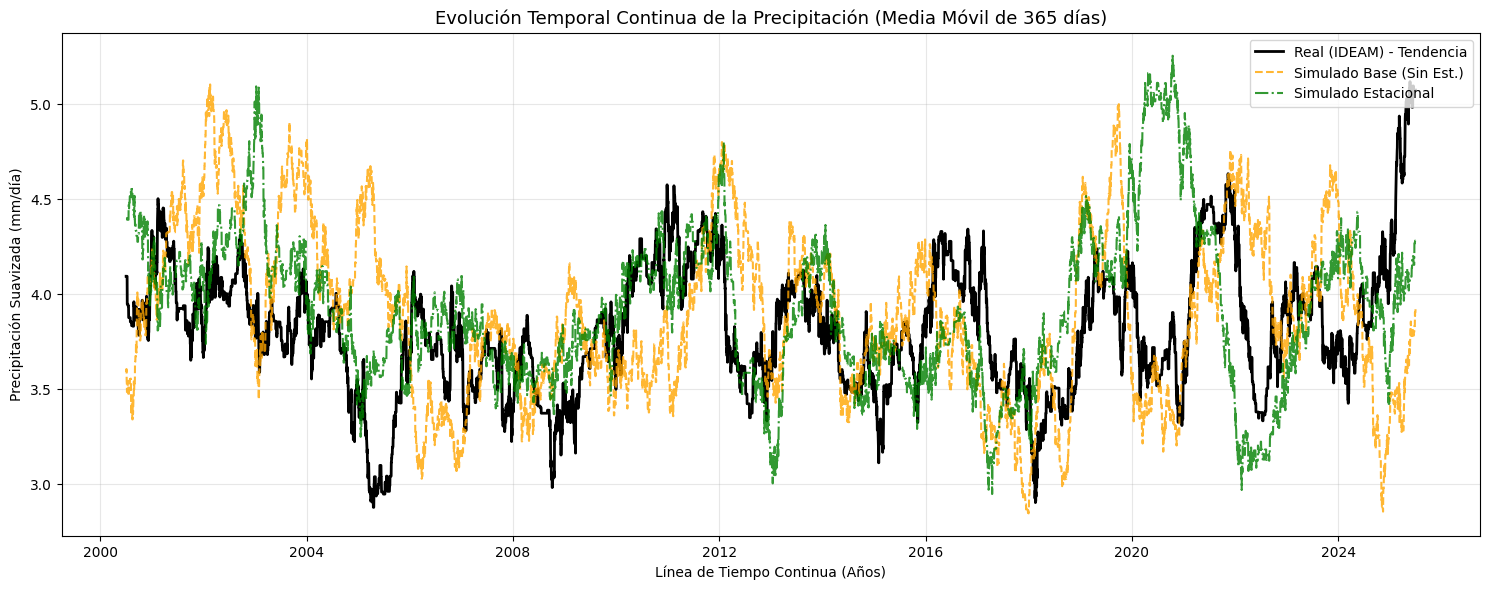

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Asegurar que el índice del DataFrame sea la fecha para el análisis continuo
df_continuous = df.set_index('Date').sort_index()

# ==============================================================================
# 🧮 1. CÁLCULO DE MÉTRICAS GLOBALES (TODO EL HORIZONTE CONTINUO)
# ==============================================================================

# Evaluamos los milímetros diarios simulados contra los reales en toda la historia
metrics_data = []
for name, col in [('Modelo Base (Sin Est.)', 'Precip_Sim_Base'), ('Modelo Estacional', 'Precip_Sim_Season')]:
    mae = mean_absolute_error(df_continuous['Precipitation_mm'], df_continuous[col])
    rmse = np.sqrt(mean_squared_error(df_continuous['Precipitation_mm'], df_continuous[col]))
    # Correlación de las series continuas
    corr = df_continuous['Precipitation_mm'].corr(df_continuous[col])
    
    metrics_data.append({
        'Modelo': name,
        'MAE Global (mm)': round(mae, 4),
        'RMSE Global (mm)': round(rmse, 4),
        'Correlación Temporal': round(corr, 4)
    })

df_metrics = pd.DataFrame(metrics_data)


# ==============================================================================
# 📉 2. SUAVIZADO POR MEDIA MÓVIL (FILTRO TEMPORAL CONTINUO)
# ==============================================================================

# Usamos una ventana de 365 días para eliminar el ruido diario y ver la trayectoria multianual
window = 365
df_smooth = df_continuous[['Precipitation_mm', 'Precip_Sim_Base', 'Precip_Sim_Season']].rolling(window=window, center=True).mean()


# ==============================================================================
# 🖥️ 3. DESPLIEGUE DE RESULTADOS Y GRÁFICO CONTINUO
# ==============================================================================

print("======= 📑 REPORTE DE ERROR EN TODO EL HORIZONTE TEMPORAL (1990-2025) =======")
print(df_metrics.to_string(index=False))
print("=============================================================================")

plt.figure(figsize=(15, 6))

# Graficamos las series suavizadas a lo largo de los años continuos
plt.plot(df_smooth.index, df_smooth['Precipitation_mm'], label='Real (IDEAM) - Tendencia', color='black', linewidth=2)
plt.plot(df_smooth.index, df_smooth['Precip_Sim_Base'], label='Simulado Base (Sin Est.)', color='orange', linestyle='--', alpha=0.8)
plt.plot(df_smooth.index, df_smooth['Precip_Sim_Season'], label='Simulado Estacional', color='green', linestyle='-.', alpha=0.8)

plt.title(f'Evolución Temporal Continua de la Precipitación (Media Móvil de {window} días)', fontsize=13)
plt.xlabel('Línea de Tiempo Continua (Años)')
plt.ylabel('Precipitación Suavizada (mm/día)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

======= 📑 REPORTE DE ERROR EN LA LÍNEA DE TIEMPO MENSUAL (1990-2025) =======
                Modelo  MAE Mensual (mm)  RMSE Mensual (mm)  Correlación Mensual
Modelo Base (Sin Est.)            2.4029             2.9521               0.0978
     Modelo Estacional            1.5711             2.0139               0.7080


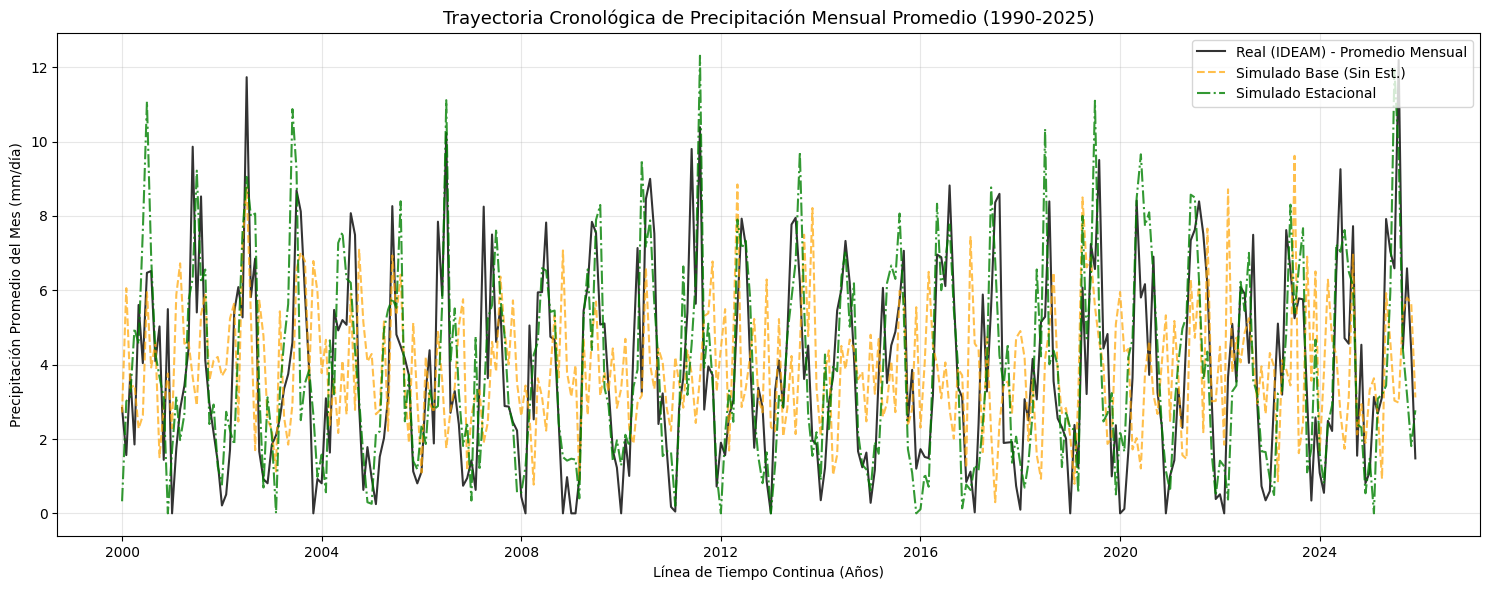

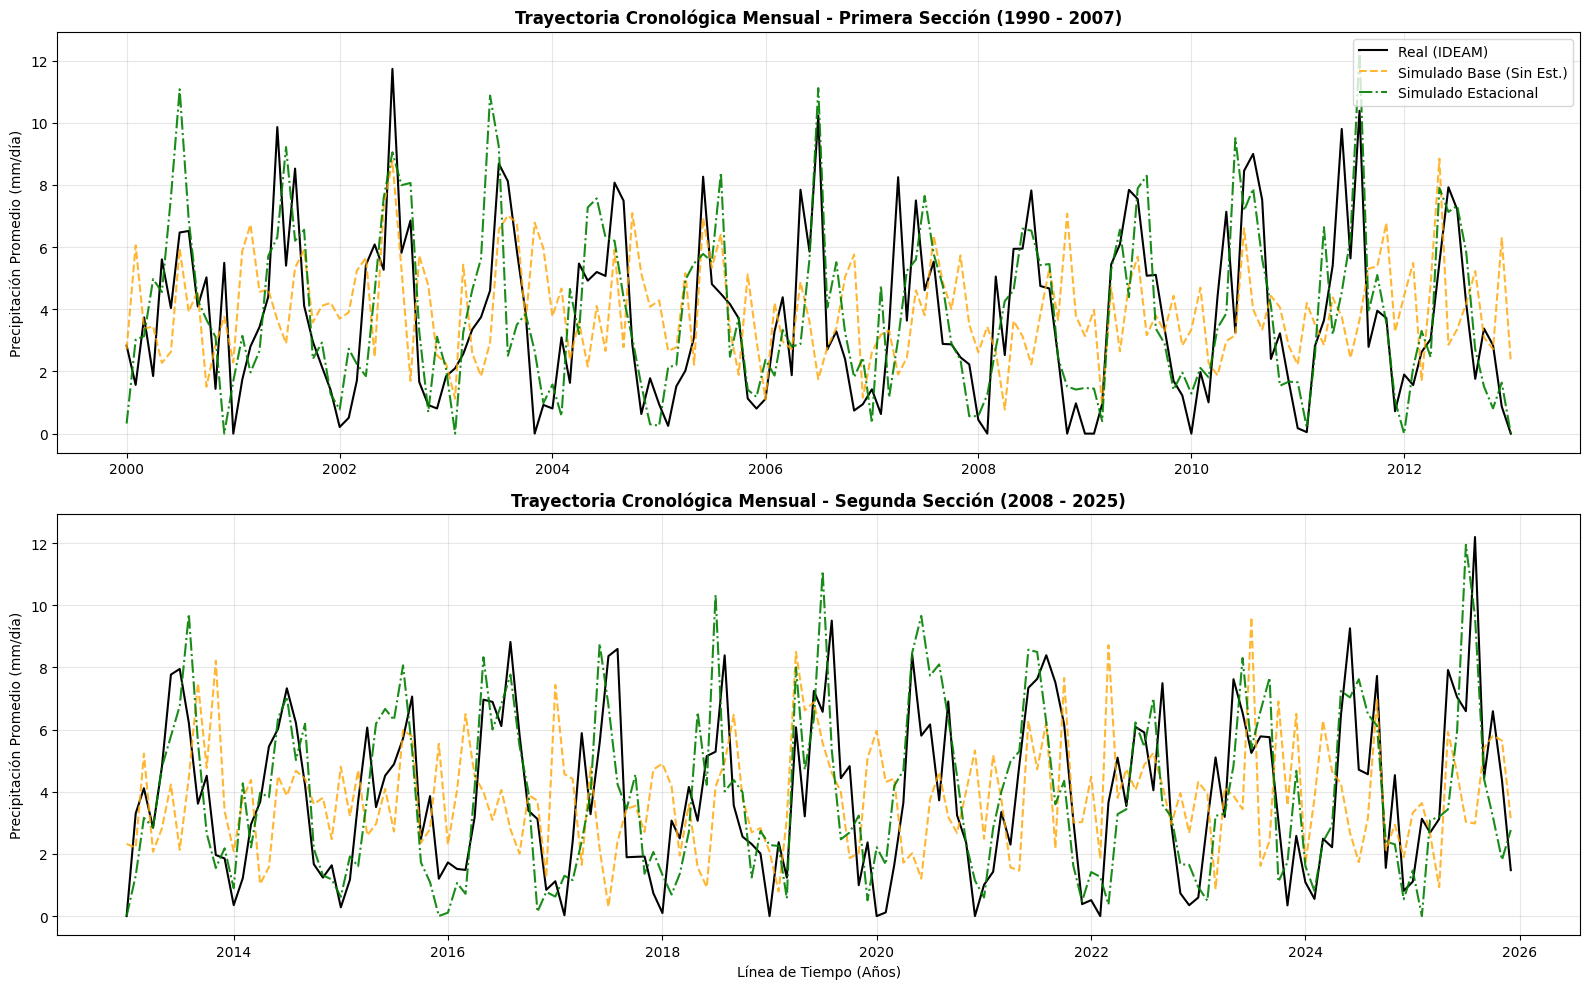

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Asegurar que el índice temporal sea correcto y esté ordenado
df_continuous = df.copy()
df_continuous['Date'] = pd.to_datetime(df_continuous['Date'])

# ==============================================================================
# 📅 1. AGRUPACIÓN MENSUAL CONTINUA (AÑO Y MES CRONOLÓGICO)
# ==============================================================================

# Creamos una columna para el periodo Año-Mes (ej: 1990-01, 1990-02...)
df_continuous['Year_Month'] = df_continuous['Date'].dt.to_period('M')

# Agrupamos por este periodo para calcular el promedio real y simulado de CADA mes histórico
df_monthly_timeline = df_continuous.groupby('Year_Month').agg({
    'Precipitation_mm': 'mean',
    'Precip_Sim_Base': 'mean',
    'Precip_Sim_Season': 'mean'
}).rename(columns={
    'Precipitation_mm': 'mm_Real_Mensual',
    'Precip_Sim_Base': 'mm_Base_Mensual',
    'Precip_Sim_Season': 'mm_Season_Mensual'
})

# Convertimos el índice de Period a Datetime para que Matplotlib lo grafique sin problemas
df_monthly_timeline.index = df_monthly_timeline.index.to_timestamp()


# ==============================================================================
# 🧮 2. CÁLCULO DE MÉTRICAS SOBRE LA SERIE MENSUAL CONTINUA
# ==============================================================================

metrics_monthly = []
for name, col in [('Modelo Base (Sin Est.)', 'mm_Base_Mensual'), ('Modelo Estacional', 'mm_Season_Mensual')]:
    mae = mean_absolute_error(df_monthly_timeline['mm_Real_Mensual'], df_monthly_timeline[col])
    rmse = np.sqrt(mean_squared_error(df_monthly_timeline['mm_Real_Mensual'], df_monthly_timeline[col]))
    corr = df_monthly_timeline['mm_Real_Mensual'].corr(df_monthly_timeline[col])
    
    metrics_monthly.append({
        'Modelo': name,
        'MAE Mensual (mm)': round(mae, 4),
        'RMSE Mensual (mm)': round(rmse, 4),
        'Correlación Mensual': round(corr, 4)
    })

df_metrics_monthly = pd.DataFrame(metrics_monthly)


# ==============================================================================
# 🖥️ 3. DESPLIEGUE DE REPORTES Y GRÁFICO CRONOLÓGICO MENSUAL
# ==============================================================================

print("======= 📑 REPORTE DE ERROR EN LA LÍNEA DE TIEMPO MENSUAL (1990-2025) =======")
print(df_metrics_monthly.to_string(index=False))
print("=============================================================================")

plt.figure(figsize=(15, 6))

# Graficamos la evolución cronológica mes a mes
plt.plot(df_monthly_timeline.index, df_monthly_timeline['mm_Real_Mensual'], 
         label='Real (IDEAM) - Promedio Mensual', color='black', linewidth=1.5, alpha=0.8)
plt.plot(df_monthly_timeline.index, df_monthly_timeline['mm_Base_Mensual'], 
         label='Simulado Base (Sin Est.)', color='orange', linestyle='--', alpha=0.7)
plt.plot(df_monthly_timeline.index, df_monthly_timeline['mm_Season_Mensual'], 
         label='Simulado Estacional', color='green', linestyle='-.', alpha=0.8)

plt.title('Trayectoria Cronológica de Precipitación Mensual Promedio (1990-2025)', fontsize=13)
plt.xlabel('Línea de Tiempo Continua (Años)')
plt.ylabel('Precipitación Promedio del Mes (mm/día)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ==============================================================================
# ✂️ 1. DIVISIÓN DEL HORIZONTE EN DOS SECCIONES
# ==============================================================================

# Calculamos el punto medio de la serie cronológica mensual
split_date = df_monthly_timeline.index[len(df_monthly_timeline) // 2]

df_part1 = df_monthly_timeline.loc[:split_date]
df_part2 = df_monthly_timeline.loc[split_date:]


# ==============================================================================
# 🖥️ 2. GENERACIÓN DE GRÁFICOS EN DOS PANELES (SUBPLOTS)
# ==============================================================================

fig, ax = plt.subplots(2, 1, figsize=(16, 10), sharey=True)

# 📉 PANEL 1: Primera mitad de la historia (1990 - 2007)
ax[0].plot(df_part1.index, df_part1['mm_Real_Mensual'], label='Real (IDEAM)', color='black', linewidth=1.5)
ax[0].plot(df_part1.index, df_part1['mm_Base_Mensual'], label='Simulado Base (Sin Est.)', color='orange', linestyle='--', alpha=0.8)
ax[0].plot(df_part1.index, df_part1['mm_Season_Mensual'], label='Simulado Estacional', color='green', linestyle='-.', alpha=0.9)
ax[0].set_title('Trayectoria Cronológica Mensual - Primera Sección (1990 - 2007)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Precipitación Promedio (mm/día)')
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc='upper right')

# 📉 PANEL 2: Segunda mitad de la historia (2008 - 2025)
ax[1].plot(df_part2.index, df_part2['mm_Real_Mensual'], color='black', linewidth=1.5)
ax[1].plot(df_part2.index, df_part2['mm_Base_Mensual'], color='orange', linestyle='--', alpha=0.8)
ax[1].plot(df_part2.index, df_part2['mm_Season_Mensual'], color='green', linestyle='-.', alpha=0.9)
ax[1].set_title('Trayectoria Cronológica Mensual - Segunda Sección (2008 - 2025)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Línea de Tiempo (Años)')
ax[1].set_ylabel('Precipitación Promedio (mm/día)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()